<a href="https://colab.research.google.com/github/SamShinwari/Advanced-AI-Bootcamp-2026/blob/main/Project_7_Bag_of_Words_(BoW)_using_CountVectorizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# What is Bag of Words?

Bag of Words represents a document by counting how many times each word appears.

### Example

Suppose we have three news headlines:

```text
D1: Ukraine war begins

D2: Russia attacks Ukraine

D3: Ukraine wins war
```

### Vocabulary

```text
Ukraine
War
Begins
Russia
Attacks
Wins
```

### Bag of Words Matrix

| Document | Ukraine | War | Begins | Russia | Attacks | Wins |
| -------- | ------- | --- | ------ | ------ | ------- | ---- |
| D1       | 1       | 1   | 1      | 0      | 0       | 0    |
| D2       | 1       | 0   | 0      | 1      | 1       | 0    |
| D3       | 1       | 1   | 0      | 0      | 0       | 1    |

This matrix becomes the input to ML algorithms.

In [6]:
import nltk

Download the English model:

In [7]:
# Download required resources (run once)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

---

# Step 2: Import Libraries

In [8]:
import pandas as pd
import spacy
from google.colab import drive
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

In [9]:
import re
import nltk
from nltk.corpus import stopwords

# Download stopwords (run once)
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [10]:
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
nlp = spacy.load("en_core_web_sm")
# Download required resources (run once)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

---

# Step 4: Load Dataset

In [12]:
file_path = '/content/drive/MyDrive/Colab Notebooks/bbc_dataset.csv'
df = pd.read_csv(file_path)
df.head()

,title,pubDate,guid,link,description
0,Ukraine: Angry Zelensky vows to punish Russian...,"Mon, 07 Mar 2022 08:01:56 GMT",https://www.bbc.co.uk/news/world-europe-60638042,https://www.bbc.co.uk/news/world-europe-606380...,The Ukrainian president says the country will ...
1,War in Ukraine: Taking cover in a town under a...,"Sun, 06 Mar 2022 22:49:58 GMT",https://www.bbc.co.uk/news/world-europe-60641873,https://www.bbc.co.uk/news/world-europe-606418...,"Jeremy Bowen was on the frontline in Irpin, as..."
2,Ukraine war 'catastrophic for global food',"Mon, 07 Mar 2022 00:14:42 GMT",https://www.bbc.co.uk/news/business-60623941,https://www.bbc.co.uk/news/business-60623941?a...,One of the world's biggest fertiliser firms sa...
3,Manchester Arena bombing: Saffie Roussos's par...,"Mon, 07 Mar 2022 00:05:40 GMT",https://www.bbc.co.uk/news/uk-60579079,https://www.bbc.co.uk/news/uk-60579079?at_medi...,The parents of the Manchester Arena bombing's ...
4,Ukraine conflict: Oil price soars to highest l...,"Mon, 07 Mar 2022 08:15:53 GMT",https://www.bbc.co.uk/news/business-60642786,https://www.bbc.co.uk/news/business-60642786?a...,Consumers are feeling the impact of higher ene...


In [13]:
df = df.dropna(subset=["description"])
df = df.drop_duplicates(subset=["description"])
df = df.reset_index(drop=True)

In [14]:
df = df.drop(columns=['guid', 'link','pubDate'])
df.head()

,title,description
0,Ukraine: Angry Zelensky vows to punish Russian...,The Ukrainian president says the country will ...
1,War in Ukraine: Taking cover in a town under a...,"Jeremy Bowen was on the frontline in Irpin, as..."
2,Ukraine war 'catastrophic for global food',One of the world's biggest fertiliser firms sa...
3,Manchester Arena bombing: Saffie Roussos's par...,The parents of the Manchester Arena bombing's ...
4,Ukraine conflict: Oil price soars to highest l...,Consumers are feeling the impact of higher ene...


## Text Cleaning

Before applying Bag of Words, we need to clean the text data. This typically involves:

1.  **Lowercasing**: Converting all text to lowercase to treat words like "The" and "the" as the same.
2.  **Removing Punctuation and Numbers**: Eliminating special characters and digits that don't contribute to the meaning.
3.  **Tokenization**: Breaking down text into individual words or tokens.
4.  **Removing Stopwords**: Eliminating common words (e.g., "a", "an", "the", "is") that often carry little semantic value and can add noise to the analysis.

In [15]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower() # Lowercasing
    text = re.sub(r'[^a-z ]', '', text) # Remove punctuation and numbers (keep only lowercase letters and spaces)
    tokens = nltk.word_tokenize(text) # Tokenization
    filtered_tokens = [word for word in tokens if word not in stop_words] # Remove stopwords
    return ' '.join(filtered_tokens)

df['clean_text'] = df['description'].apply(clean_text)

display(df[['description', 'clean_text']].head())

,description,clean_text
0,The Ukrainian president says the country will ...,ukrainian president says country forgive forge...
1,"Jeremy Bowen was on the frontline in Irpin, as...",jeremy bowen frontline irpin residents came ru...
2,One of the world's biggest fertiliser firms sa...,one worlds biggest fertiliser firms says confl...
3,The parents of the Manchester Arena bombing's ...,parents manchester arena bombings youngest vic...
4,Consumers are feeling the impact of higher ene...,consumers feeling impact higher energy costs f...


---

# What is Bag of Words?

Bag of Words represents a document by counting how many times each word appears.

### Example

Suppose we have three news headlines:

```text
D1: Ukraine war begins

D2: Russia attacks Ukraine

D3: Ukraine wins war
```

### Vocabulary

```text
Ukraine
War
Begins
Russia
Attacks
Wins
```

### Bag of Words Matrix

| Document | Ukraine | War | Begins | Russia | Attacks | Wins |
| -------- | ------- | --- | ------ | ------ | ------- | ---- |
| D1       | 1       | 1   | 1      | 0      | 0       | 0    |
| D2       | 1       | 0   | 0      | 1      | 1       | 0    |
| D3       | 1       | 1   | 0      | 0      | 0       | 1    |

This matrix becomes the input to ML algorithms.

---

---

# Step 4: Create CountVectorizer

In [16]:
vectorizer = CountVectorizer()

---

# Step 5: Convert Text into BoW Matrix

In [17]:
X = vectorizer.fit_transform(df["clean_text"])

---

# Step 6: Check Matrix Shape

In [18]:
print(X.shape)

(33124, 31485)


---

# Step 7: Vocabulary

In [19]:
print(vectorizer.get_feature_names_out())

['aa' 'aaliyah' 'aamir' ... 'zverevs' 'zwelithini' 'zwerner']


---

# Step 8: Vocabulary Size

In [20]:
print("Vocabulary Size:", len(vectorizer.get_feature_names_out()))

Vocabulary Size: 31485


---

# Step 9: Convert Matrix into DataFrame

In [21]:
bow_df = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)

display(bow_df.head())

,aa,aaliyah,aamir,aanoch,aardman,aaron,aarons,aastha,ab,abandon,...,zunino,zunyou,zurcher,zurich,zuu,zuwara,zverev,zverevs,zwelithini,zwerner
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


---

# Step 10: Display First Document Vector

In [22]:
print(bow_df.iloc[0])

aa            0
aaliyah       0
aamir         0
aanoch        0
aardman       0
             ..
zuwara        0
zverev        0
zverevs       0
zwelithini    0
zwerner       0
Name: 0, Length: 31485, dtype: int64


---

# Step 11: Total Frequency of Every Word

In [23]:
word_frequency = bow_df.sum(axis=0)

print(word_frequency.sort_values(
    ascending=False
).head(20))

says          3747
world         1735
bbc           1544
england       1524
first         1517
new           1495
people        1487
cup           1392
say           1312
league        1183
two           1097
one           1097
years         1058
uk            1043
win           1007
us            1001
police         869
former         852
manchester     839
could          835
dtype: int64


---

# Step 12: Limit Vocabulary Size

In [24]:
vectorizer = CountVectorizer(
    max_features=1000
)

X = vectorizer.fit_transform(df["clean_text"])

print(X.shape)

(33124, 1000)


---

# Step 13: Remove Very Common Words

Ignore words appearing in more than **80%** of documents.

In [25]:
vectorizer = CountVectorizer(
    max_df=0.80
)

X = vectorizer.fit_transform(df["clean_text"])

---

# Step 14: Remove Rare Words

Ignore words appearing in fewer than **2** documents.

In [26]:
vectorizer = CountVectorizer(
    min_df=2
)

X = vectorizer.fit_transform(df["clean_text"])

---

# Step 15: Use Bigrams

BoW can also include two-word phrases.

In [27]:
vectorizer = CountVectorizer(
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(df["clean_text"])

print(X.shape)

(33124, 266592)


---

# Step 16: Visualize Most Frequent Words

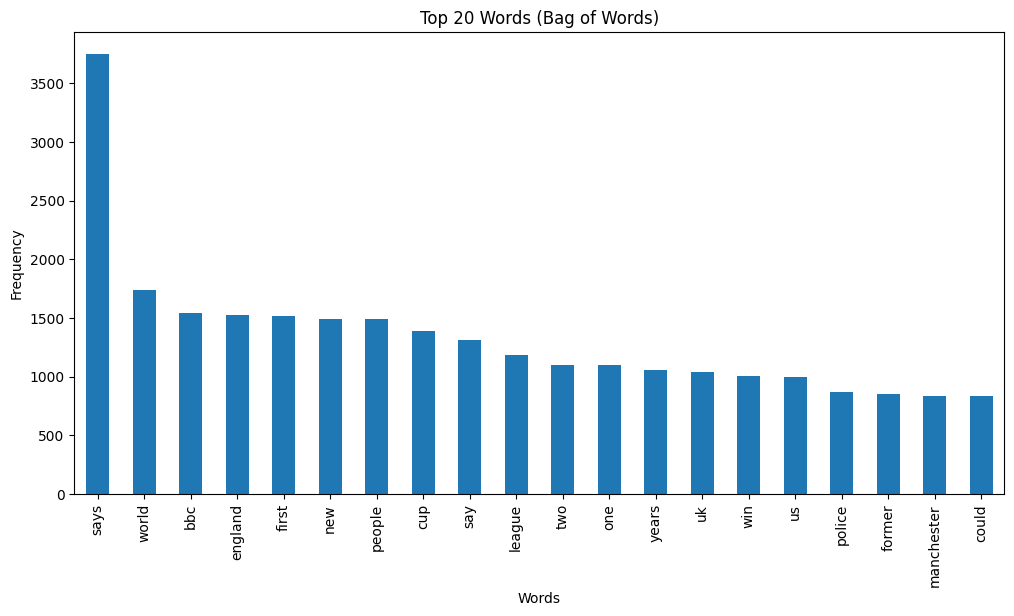

In [28]:
# Re-create bow_df with default CountVectorizer for visualization
vectorizer_full = CountVectorizer()
X_full = vectorizer_full.fit_transform(df["clean_text"])
bow_df_full = pd.DataFrame(
    X_full.toarray(),
    columns=vectorizer_full.get_feature_names_out()
)

freq = bow_df_full.sum(axis=0)

top20 = freq.sort_values(
    ascending=False
).head(20)

plt.figure(figsize=(12,6))

top20.plot(kind="bar")

plt.title("Top 20 Words (Bag of Words)")

plt.xlabel("Words")

plt.ylabel("Frequency")

plt.show()

---

# Step 17: Save BoW Matrix

In [ ]:
bow_df_full.to_csv(
    "bag_of_words.csv",
    index=False
)

print("Saved Successfully")

---

# Advantages of Bag of Words

* Easy to understand and implement.
* Fast to compute.
* Works well with traditional machine learning algorithms.
* Effective for document classification.

---

# Limitations of Bag of Words

* Ignores word order.
* Does not capture context or meaning.
* Produces large sparse matrices.
* Cannot distinguish synonyms (e.g., *car* vs. *automobile*).
* Gives equal importance to common and informative words.

---

# Real-World Applications

* Spam email detection
* News article classification
* Sentiment analysis
* Topic classification
* Document clustering
* Search and information retrieval